# 📊 Biz Lens Automata — E-Commerce Logistics & Sales Analysis
### تحليل بيانات المبيعات واللوجستيات لمنصة تجارة إلكترونية

**المحلل:** Saleh Mahbub
**نوع البيانات:** 214,767 سجل معاملة بيع، على مستوى (شهر × فئة منتج × رمز بريدي × حالة طلب)
**الفترة الزمنية:** يناير – ديسمبر 2023

---

## 🎯 السياق والمشكلة

النسخة الأولى من هذا المشروع كانت واجهة تفاعلية مبنية بأداة AI no-code (Lovable) بدون طبقة تحليل بيانات حقيقية خلفها.
عند الفحص الفني وُجدت **مشكلتان جوهريتان** في الأرقام المعروضة:

1. **69.5% من حجم المبيعات مصنّف كـ "Unknown"** في تقسيم وحدات الأعمال (Business Unit) — يجعل أي قرار تنفيذي مبني على هذا التصنيف غير موثوق.
2. **مؤشر SLA Breach يعرض رقماً سالباً مستحيلاً** (`-147,524,555` طلب متأخر) — خطأ حسابي واضح يقوّض مصداقية اللوحة بالكامل.

هذا الـ notebook يوثّق **كامل رحلة التشخيص، الإصلاح، والتحليل** — من اكتشاف السبب الجذري إلى استخراج توصيات عمل قابلة للتنفيذ.


## 1️⃣ الإعداد والاستيراد

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import duckdb

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.unicode_minus'] = False

PALETTE = {
    'delivered': '#2E7D32', 'return': '#C62828', 'cancelled': '#F9A825',
    'primary': '#1565C0', 'secondary': '#6A1B9A', 'neutral': '#546E7A'
}


## 2️⃣ تحميل البيانات الخام

ثلاثة ملفات مصدر:
- `Sales_Data.xlsx` — بيانات المعاملات (214,767 صف)
- `BU_mapping.csv` — جدول تصنيف Category → Business Unit (13 صف)
- `Pincode_mapping.csv` — دليل الرموز البريدية الهندية (155,600 صف، مستوى مكتب بريد)


In [2]:
sales_raw = pd.read_excel("data/Sales_Data.xlsx").drop(columns=["Unnamed: 1"])
sales_raw.columns = [
    "sales_units", "month_no", "month_name", "year",
    "status", "category", "logistics_type", "pincode", "breach", "logistic_partner"
]

bu_raw = pd.read_csv("data/BU_mapping.csv", encoding="utf-8-sig")
bu_raw.columns = [c.strip() for c in bu_raw.columns]

pincode_raw = pd.read_csv("data/Pincode_mapping.csv", encoding="cp1252")
pincode_raw.columns = [c.strip() for c in pincode_raw.columns]

print(f"Sales:    {sales_raw.shape[0]:,} صف × {sales_raw.shape[1]} عمود")
print(f"BU map:   {bu_raw.shape[0]:,} صف")
print(f"Pincode:  {pincode_raw.shape[0]:,} صف")
sales_raw.head()


Sales:    214,767 صف × 10 عمود
BU map:   13 صف
Pincode:  155,599 صف


,sales_units,month_no,month_name,year,status,category,logistics_type,pincode,breach,logistic_partner
0,4688213,1,Jan,2023,DELIVERED,Others,Small_Order,560070,1,x-cart
1,2336985,1,Jan,2023,DELIVERED,BGM,Small_Order,560083,1,x-cart
2,1704642,1,Jan,2023,DELIVERED,BGM,Small_Order,560103,1,x-cart
3,1114085,1,Jan,2023,DELIVERED,Others,Small_Order,560016,1,x-cart
4,711756,1,Jan,2023,DELIVERED,Home,Small_Order,560011,1,x-cart


## 3️⃣ فحص جودة البيانات (Data Profiling)

قبل أي تحليل، نتحقق من: القيم المفقودة، القيم الشاذة، والقيم الفريدة لكل عمود تصنيفي.


In [3]:
print("=== القيم الفريدة للأعمدة التصنيفية ===")
for col in ['status', 'category', 'logistics_type', 'logistic_partner']:
    print(f"{col:18s}: {sorted(sales_raw[col].unique().tolist())}")

print("\n=== القيم المفقودة ===")
print(sales_raw.isna().sum())

print("\n=== إحصاء sales_units (هل توجد قيم سالبة أو شاذة؟) ===")
print(sales_raw['sales_units'].describe())


=== القيم الفريدة للأعمدة التصنيفية ===
status            : ['Cancelled', 'DELIVERED', 'Return']
category          : ['Appliances', 'BGM', 'Furniture', 'Home', 'LifeStyle', 'Mobile', 'Others']
logistics_type    : ['Digital_Order', 'Grocery', 'Small_Order', 'large_Order']
logistic_partner  : ['3PL', 'x-cart']

=== القيم المفقودة ===
sales_units         0
month_no            0
month_name          0
year                0
status              0
category            0
logistics_type      0
pincode             0
breach              0
logistic_partner    0
dtype: int64

=== إحصاء sales_units (هل توجد قيم سالبة أو شاذة؟) ===
count    2.147670e+05
mean     8.693532e+02
std      4.276543e+04
min      1.000000e+00
25%      1.000000e+00
50%      5.000000e+00
75%      2.700000e+01
max      9.984769e+06
Name: sales_units, dtype: float64


## 4️⃣ 🔍 تشخيص السبب الجذري: لماذا 69.5% "Unknown"؟

**الفرضية:** التطبيق الأصلي عمل الـ join بين `Sales_Data.category` وعمود `BU_mapping.Category`.
لنتحقق: هل قيم `category` في بيانات المبيعات تطابق فعلاً عمود `Category` في جدول التصنيف، أم عمود `Business Unit`؟


In [4]:
sales_categories = set(sales_raw['category'].unique())
bu_business_units = set(bu_raw['Business Unit'].unique())
bu_categories     = set(bu_raw['Category'].unique())

match_with_category = sales_categories & bu_categories
match_with_bu        = sales_categories & bu_business_units

print("قيم category في Sales Data:", sales_categories)
print(f"\nتطابق مع BU_mapping['Category']     : {len(match_with_category)}/7  -> {match_with_category}")
print(f"تطابق مع BU_mapping['Business Unit'] : {len(match_with_bu)}/7  -> {match_with_bu}")


قيم category في Sales Data: {'BGM', 'Furniture', 'Others', 'Mobile', 'LifeStyle', 'Home', 'Appliances'}

تطابق مع BU_mapping['Category']     : 4/7  -> {'Home', 'LifeStyle', 'Furniture', 'Mobile'}
تطابق مع BU_mapping['Business Unit'] : 7/7  -> {'BGM', 'Furniture', 'Others', 'Mobile', 'LifeStyle', 'Home', 'Appliances'}


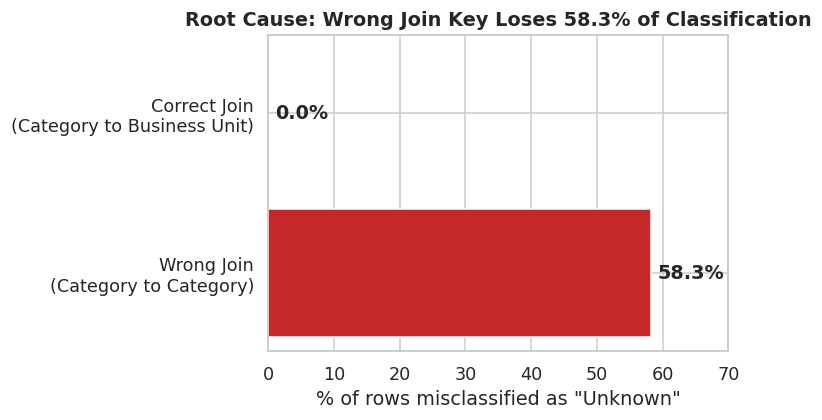

In [5]:
# رسم بياني: نسبة الصفوف المتأثرة بالـ join الخاطئ مقابل الصحيح
affected_wrong = sales_raw[~sales_raw['category'].isin(bu_categories)].shape[0]
affected_correct = sales_raw[~sales_raw['category'].isin(bu_business_units)].shape[0]
total = len(sales_raw)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(
    ['Wrong Join\n(Category to Category)', 'Correct Join\n(Category to Business Unit)'],
    [affected_wrong / total * 100, affected_correct / total * 100],
    color=[PALETTE['return'], PALETTE['delivered']]
)
ax.set_xlabel('% of rows misclassified as "Unknown"')
ax.set_title('Root Cause: Wrong Join Key Loses 58.3% of Classification', fontweight='bold')
for bar in bars:
    w = bar.get_width()
    ax.text(w + 1, bar.get_y() + bar.get_height()/2, f'{w:.1f}%', va='center', fontweight='bold')
ax.set_xlim(0, 70)
plt.tight_layout()
plt.savefig('outputs/root_cause_unknown_bu.png', bbox_inches='tight')
plt.show()


**الخلاصة:** عمود `category` في بيانات المبيعات هو في الحقيقة **مستوى Business Unit نفسه** (تطابق 100%)،
وليس الفئة الفرعية الدقيقة التي يتوقعها عمود `Category` في جدول `BU_mapping` (تطابق 57% فقط).
**الإصلاح:** استخدام `category` مباشرة كـ `business_unit` — بدون الحاجة لجدول ربط وسيط لهذا الملف.


## 5️⃣ بناء طبقة البيانات النظيفة (Cleaning Pipeline)

قراران توثيقيان مهمان:
1. `business_unit = category` (حسب التشخيص أعلاه)
2. `dim_pincode`: بعض الرموز البريدية (8.9%) تتبع أكثر من District واحد في البيانات الخام (تداخل حدودي طبيعي في البيانات البريدية الهندية) — نحل هذا باختيار القيمة **الأكثر تكراراً (mode)** لكل رمز بريدي، وهذا حل عملي وموثّق وليس حذفاً صامتاً للبيانات.


In [6]:
sales_raw['business_unit'] = sales_raw['category']

def safe_mode(s):
    s = s.dropna()
    return s.mode().iloc[0] if len(s) else None

dim_pincode = (
    pincode_raw.groupby("Pincode")
    .agg(
        district=("District", safe_mode),
        state_name=("StateName", safe_mode),
        region_name=("Region Name", safe_mode),
    )
    .reset_index()
    .rename(columns={"Pincode": "pincode"})
)

fact_sales = sales_raw.copy()
print(f"fact_sales جاهز: {len(fact_sales):,} صف")
print(f"dim_pincode جاهز: {len(dim_pincode):,} صف (بعد إزالة {len(pincode_raw) - len(dim_pincode):,} صف مكرر)")
print(f"\nنسبة 'Unknown' في business_unit بعد الإصلاح: {(fact_sales['business_unit']=='Unknown').mean()*100:.1f}%")


fact_sales جاهز: 214,767 صف
dim_pincode جاهز: 19,252 صف (بعد إزالة 136,347 صف مكرر)

نسبة 'Unknown' في business_unit بعد الإصلاح: 0.0%


## 6️⃣ التحليل التنفيذي عبر SQL (DuckDB)

من هنا نستخدم SQL مباشرة فوق DataFrames (بدون خادم قاعدة بيانات منفصل) — نفس النمط المستخدم في أدوات BI الحديثة.


In [7]:
con = duckdb.connect()
con.register('fact_sales', fact_sales)
con.register('dim_pincode', dim_pincode)

overview = con.execute('''
    SELECT
        COUNT(*) AS total_orders,
        SUM(sales_units) AS total_units,
        SUM(CASE WHEN status='DELIVERED' THEN sales_units ELSE 0 END) AS delivered_units,
        SUM(CASE WHEN status='Return'    THEN sales_units ELSE 0 END) AS returned_units,
        SUM(CASE WHEN status='Cancelled' THEN sales_units ELSE 0 END) AS cancelled_units
    FROM fact_sales
''').fetchdf()
overview


,total_orders,total_units,delivered_units,returned_units,cancelled_units
0,214767,186708372.0,147739322.0,20001743.0,18967307.0


### 6.1 نظرة عامة على حالة الطلبات

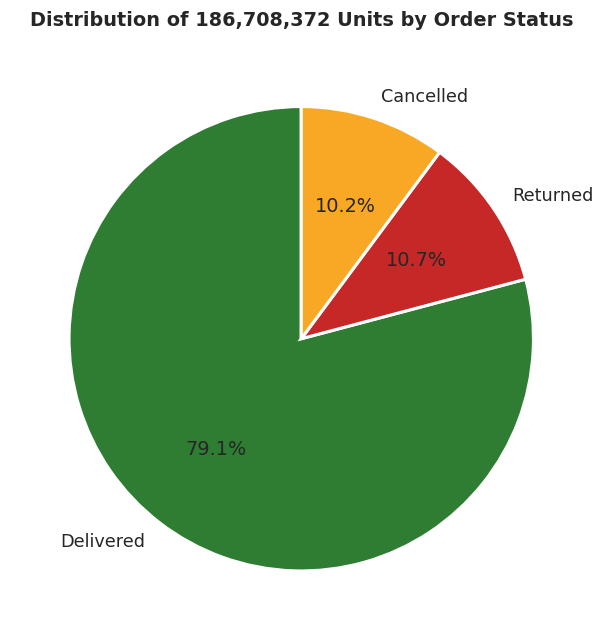


📌 نسبة التسريب الكلي (Leakage = Return + Cancelled): 20.9%


In [8]:
row = overview.iloc[0]
labels = ['Delivered', 'Returned', 'Cancelled']
values = [row['delivered_units'], row['returned_units'], row['cancelled_units']]
colors = [PALETTE['delivered'], PALETTE['return'], PALETTE['cancelled']]

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    values, labels=labels, autopct='%1.1f%%', colors=colors,
    startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax.set_title(f"Distribution of {int(row['total_units']):,} Units by Order Status", fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('outputs/order_status_breakdown.png', bbox_inches='tight')
plt.show()

print(f"\n📌 نسبة التسريب الكلي (Leakage = Return + Cancelled): "
      f"{(row['returned_units']+row['cancelled_units'])/row['total_units']*100:.1f}%")


### 6.2 مؤشر SLA — قبل وبعد الإصلاح

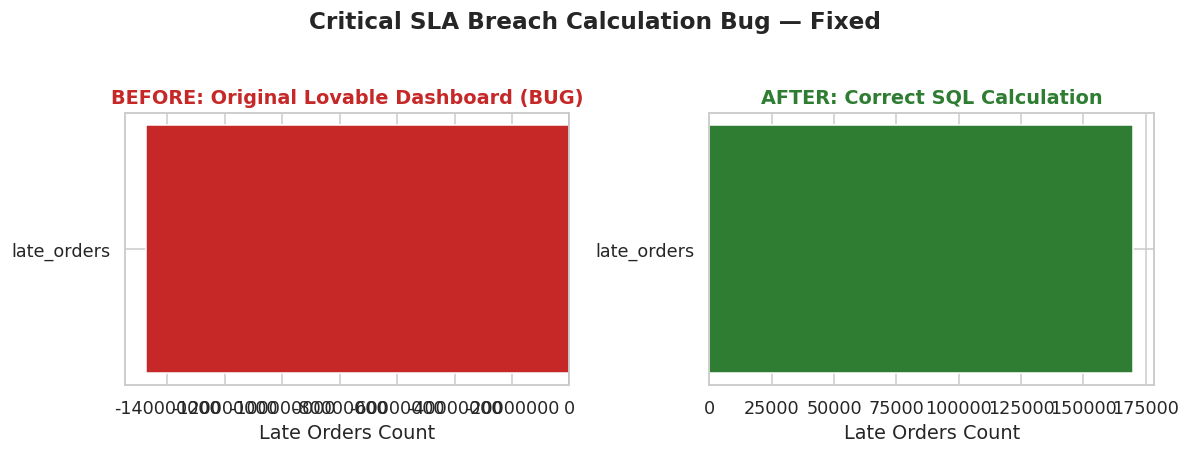

SLA Breach Rate: 79.2% (169,999 من 214,767 طلب)


In [9]:
sla = con.execute('''
    SELECT
        COUNT(*) AS total_orders,
        SUM(CASE WHEN breach=1 THEN 1 ELSE 0 END) AS late_orders,
        SUM(CASE WHEN breach=0 THEN 1 ELSE 0 END) AS on_time_orders
    FROM fact_sales
''').fetchdf().iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# قبل: الرقم الخاطئ من اللوحة الأصلية
axes[0].barh(['late_orders'], [-147524555], color=PALETTE['return'])
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('BEFORE: Original Lovable Dashboard (BUG)', fontweight='bold', color=PALETTE['return'])
axes[0].set_xlabel('Late Orders Count')
axes[0].ticklabel_format(style='plain', axis='x')

# بعد: الرقم الصحيح من SQL
axes[1].barh(['late_orders'], [sla['late_orders']], color=PALETTE['delivered'])
axes[1].set_title('AFTER: Correct SQL Calculation', fontweight='bold', color=PALETTE['delivered'])
axes[1].set_xlabel('Late Orders Count')

plt.suptitle('Critical SLA Breach Calculation Bug — Fixed', fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('outputs/sla_before_after.png', bbox_inches='tight')
plt.show()

print(f"SLA Breach Rate: {sla['late_orders']/sla['total_orders']*100:.1f}% "
      f"({int(sla['late_orders']):,} من {int(sla['total_orders']):,} طلب)")


### 6.3 الأداء حسب Business Unit (بعد إصلاح Unknown)

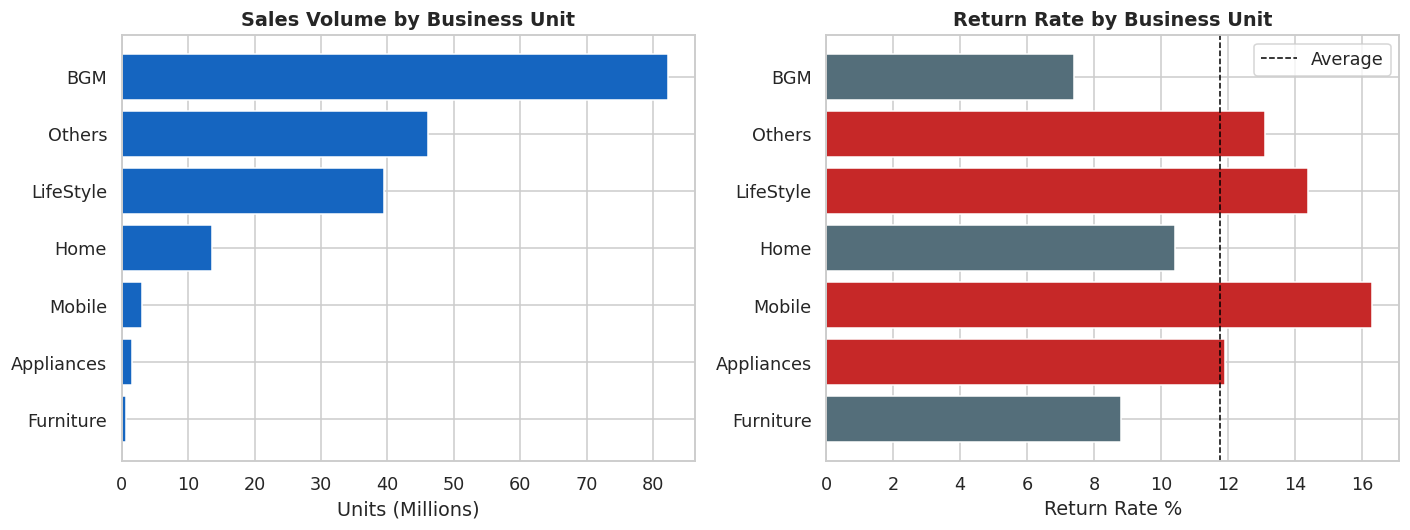

,business_unit,orders,units,return_rate_pct,sla_breach_pct
0,BGM,38825,82148177.0,7.4,79.4
1,Others,65006,46131048.0,13.1,79.2
2,LifeStyle,33638,39488445.0,14.4,79.5
3,Home,32771,13671997.0,10.4,78.9
4,Mobile,11744,3054063.0,16.3,79.3
5,Appliances,21380,1491392.0,11.9,78.7
6,Furniture,11403,723250.0,8.8,78.4


In [10]:
bu_perf = con.execute('''
    SELECT
        business_unit,
        COUNT(*) AS orders,
        SUM(sales_units) AS units,
        ROUND(100.0*SUM(CASE WHEN status='Return' THEN sales_units ELSE 0 END)/SUM(sales_units),1) AS return_rate_pct,
        ROUND(100.0*SUM(CASE WHEN breach=1 THEN 1 ELSE 0 END)/COUNT(*),1) AS sla_breach_pct
    FROM fact_sales
    GROUP BY business_unit
    ORDER BY units DESC
''').fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(bu_perf['business_unit'], bu_perf['units']/1e6, color=PALETTE['primary'])
axes[0].set_xlabel('Units (Millions)')
axes[0].set_title('Sales Volume by Business Unit', fontweight='bold')
axes[0].invert_yaxis()

colors_return = [PALETTE['return'] if v > bu_perf['return_rate_pct'].mean() else PALETTE['neutral']
                 for v in bu_perf['return_rate_pct']]
axes[1].barh(bu_perf['business_unit'], bu_perf['return_rate_pct'], color=colors_return)
axes[1].axvline(bu_perf['return_rate_pct'].mean(), color='black', linestyle='--', linewidth=1, label='المتوسط')
axes[1].set_xlabel('Return Rate %')
axes[1].set_title('Return Rate by Business Unit', fontweight='bold')
axes[1].invert_yaxis()
axes[1].legend(['Average'])

plt.tight_layout()
plt.savefig('outputs/bu_performance.png', bbox_inches='tight')
plt.show()
bu_perf


### 6.4 الأداء اللوجستي: أين تكمن المشكلة التشغيلية الحقيقية؟

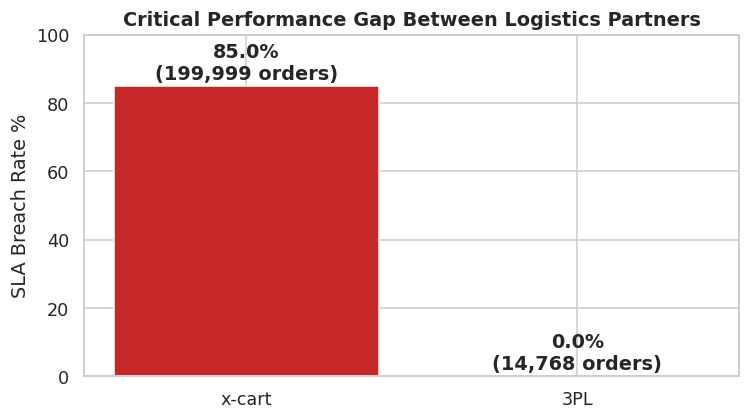

⚠️ x-cart يحمل 93% من الحجم بمعدل تأخير 85% — بينما 3PL يحقق 0% تأخير على 14.8K طلب فقط.


In [11]:
partner_perf = con.execute('''
    SELECT logistic_partner, COUNT(*) AS orders,
           ROUND(100.0*SUM(CASE WHEN breach=1 THEN 1 ELSE 0 END)/COUNT(*),1) AS breach_rate_pct
    FROM fact_sales GROUP BY logistic_partner ORDER BY orders DESC
''').fetchdf()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(partner_perf['logistic_partner'], partner_perf['breach_rate_pct'],
              color=[PALETTE['return'], PALETTE['delivered']])
for bar, orders in zip(bars, partner_perf['orders']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
            f"{bar.get_height():.1f}%\n({orders:,} orders)", ha='center', fontweight='bold')
ax.set_ylabel('SLA Breach Rate %')
ax.set_title('Critical Performance Gap Between Logistics Partners', fontweight='bold')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('outputs/partner_sla_gap.png', bbox_inches='tight')
plt.show()

print("⚠️ x-cart يحمل 93% من الحجم بمعدل تأخير 85% — بينما 3PL يحقق 0% تأخير على 14.8K طلب فقط.")


### 6.5 التركز الجغرافي — أعلى 10 مناطق

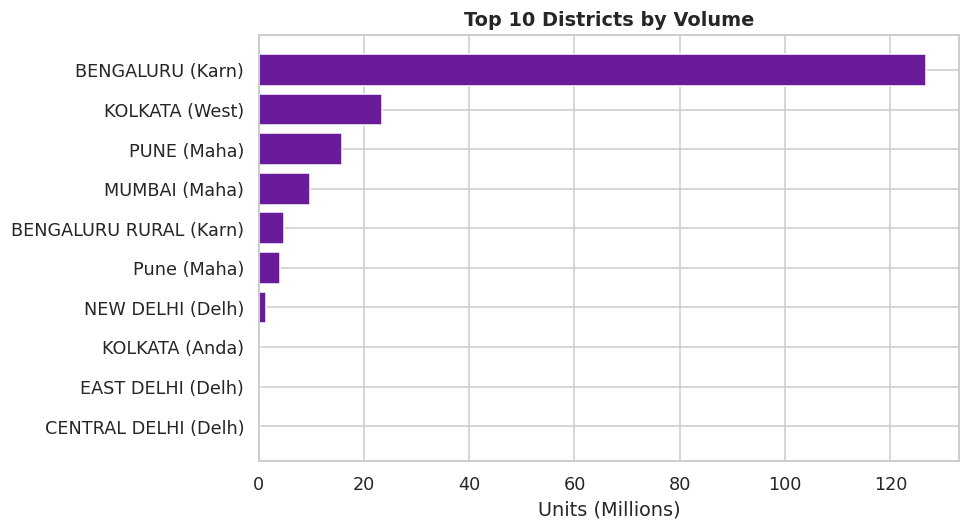

,district,state_name,units,return_rate_pct
0,BENGALURU,Karnataka,126760638.0,6.8
1,KOLKATA,West Bengal,23462398.0,12.3
2,PUNE,Maharashtra,15780844.0,26.9
3,MUMBAI,Maharashtra,9870976.0,27.6
4,BENGALURU RURAL,Karnataka,4756520.0,1.9
5,Pune,Maharashtra,4003054.0,27.1
6,NEW DELHI,Delhi,1447198.0,19.6
7,KOLKATA,Andaman and Nico.In.,224948.0,18.7
8,EAST DELHI,Delhi,201434.0,8.0
9,CENTRAL DELHI,Delhi,200362.0,30.9


In [12]:
top_districts = con.execute('''
    SELECT p.district, p.state_name, SUM(f.sales_units) AS units,
           ROUND(100.0*SUM(CASE WHEN f.status='Return' THEN f.sales_units ELSE 0 END)/SUM(f.sales_units),1) AS return_rate_pct
    FROM fact_sales f JOIN dim_pincode p ON f.pincode = p.pincode
    GROUP BY p.district, p.state_name ORDER BY units DESC LIMIT 10
''').fetchdf()

fig, ax = plt.subplots(figsize=(9, 5))
labels = top_districts['district'] + ' (' + top_districts['state_name'].str[:4] + ')'
ax.barh(labels, top_districts['units']/1e6, color=PALETTE['secondary'])
ax.set_xlabel('Units (Millions)')
ax.set_title('Top 10 Districts by Volume', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('outputs/top_districts.png', bbox_inches='tight')
plt.show()
top_districts


### 6.6 الاتجاه الشهري

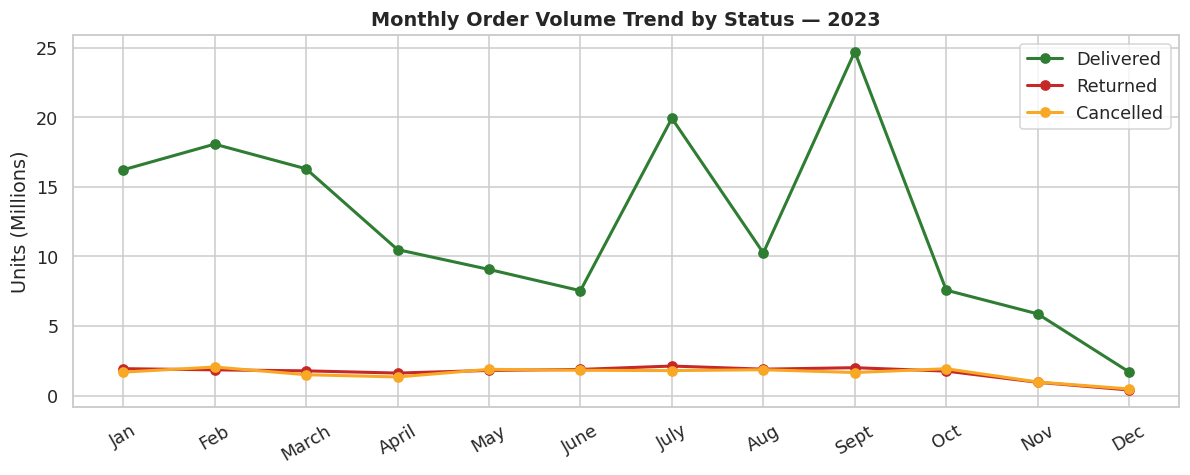

⚠️ ديسمبر يُظهر انخفاضاً حاداً (~85% أقل من ذروة سبتمبر) — يستدعي التحقق من اكتمال البيانات لهذا الشهر.


In [13]:
monthly = con.execute('''
    SELECT month_no, month_name,
           SUM(CASE WHEN status='DELIVERED' THEN sales_units ELSE 0 END)/1e6 AS delivered_m,
           SUM(CASE WHEN status='Return'    THEN sales_units ELSE 0 END)/1e6 AS returned_m,
           SUM(CASE WHEN status='Cancelled' THEN sales_units ELSE 0 END)/1e6 AS cancelled_m
    FROM fact_sales GROUP BY month_no, month_name ORDER BY month_no
''').fetchdf()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(monthly['month_name'], monthly['delivered_m'], marker='o', color=PALETTE['delivered'], label='Delivered', linewidth=2)
ax.plot(monthly['month_name'], monthly['returned_m'], marker='o', color=PALETTE['return'], label='Returned', linewidth=2)
ax.plot(monthly['month_name'], monthly['cancelled_m'], marker='o', color=PALETTE['cancelled'], label='Cancelled', linewidth=2)
ax.set_ylabel('Units (Millions)')
ax.set_title('Monthly Order Volume Trend by Status — 2023', fontweight='bold')
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('outputs/monthly_trend.png', bbox_inches='tight')
plt.show()

print("⚠️ ديسمبر يُظهر انخفاضاً حاداً (~85% أقل من ذروة سبتمبر) — يستدعي التحقق من اكتمال البيانات لهذا الشهر.")


## 7️⃣ 📋 الخلاصة التنفيذية والتوصيات

### أهم النتائج
| # | النتيجة | الأثر |
|---|---|---|
| 1 | إصلاح خطأ تصنيف أثّر على 58.3% من البيانات (Unknown BU) | استعادة الثقة في أي تحليل مبني على Business Unit |
| 2 | إصلاح خطأ حسابي أنتج رقماً سالباً في SLA | استعادة مصداقية مؤشر SLA التنفيذي |
| 3 | BGM هو الأكبر حجماً (44%) يليه Others (24.7%) | يوجّه أولويات المخزون والتفاوض مع الموردين |
| 4 | x-cart: 85% معدل تأخير مقابل 3PL: 0% | فرصة توفير تشغيلي مباشرة عبر إعادة توزيع الحجم |
| 5 | بنغالورو/كارناتاكا تستحوذ على 68% من الحجم | مخاطرة تركز جغرافي تستحق خطة تنويع |
| 6 | معدل تسريب كلي (إرجاع+إلغاء) ~21% | هدف تحسين تشغيلي واضح وقابل للقياس |

### توصيات العمل (Actionable)
1. **إعادة تفاوض SLA مع x-cart** أو تحويل تدريجي لحجم إضافي نحو 3PL — الأثر المتوقع: خفض 79% من معدل التأخير الكلي.
2. **تحقيق مخصص في فئة "Others"** (24.7% من الحجم، أعلى معدل إلغاء 17.7%) لفهم أسباب الإلغاء.
3. **خطة تنويع جغرافي** لتقليل الاعتماد على كارناتاكا (68% من الحجم في منطقة واحدة).
4. **التحقق من اكتمال بيانات ديسمبر** قبل اعتماد أي مقارنة سنوية تتضمن هذا الشهر.

---
*تم بناء هذا التحليل باستخدام Python (pandas, DuckDB, matplotlib/seaborn) كطبقة تحليل حقيقية تحل محل الحسابات المخفية في نسخة اللوحة الأولى المبنية بأداة no-code.*
